In [1]:
import cv2
import time
import re
import base64
import json
import io
import os
import traceback
import numpy as np 
import robotic as ry
import matplotlib.pyplot as plt
from PIL import Image
from dotenv import load_dotenv
from openai import OpenAI

from pathlib import Path
from datetime import datetime

from WayTu_RAI.GenerateEnvironment import GenerateEnvironment, PlacementError
import WayTu_RAI.model_utils as mutils

load_dotenv()  # loads OPENAI_API_KEY from .env
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY")) 

ry.params_add({'physx/motorKp': 10000., 
               'physx/motorK  d': 1000., 
               'physx/angularDamping': 10., 
               'physx/defaultFriction': 1000.})

ry.params_add({'botsim/engine': 'physx'})
ry.params_add({'physx/multibody': True})
ry.params_print()

print(ry.__version__)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
0.1.10
physx/motorKp: 10000,
physx/motorK  d: 1000,
physx/angularDamping: 10,
physx/defaultFriction: 1000,
botsim/engine: physx,
physx/multibody

In [2]:
parameters = {
    "num-trials"        : 10,
    "num-tools"         : 3,
    "tool-type"         : 'primitive',
    "task"              : 'lifting',
    "mode"              : 'test',
    "area-middle"       : { "min": [-0.35 , 0.15, 0.060], "max": [ 0.35 , 0.45, 0.065] },
    "area-negative"     : { "min": [-0.50 , 0.15, 0.050], "max": [ -0.35 , 0.45, 0.060] },
    "area-positive"     : { "min": [0.40 , 0.15, 0.050], "max": [ 0.50 , 0.45, 0.060] },
    "label-list-all"    : ["lifting-platform", "minigolf-platform", "hammering-platform", "hammer", "spatula", "L-ruler", "screwdriver", "ball", "book", "thin-stick", "ring"],
    "cameras"           : ["camera5"],
}

In [3]:
def draw_rgb_and_depth(rgb, depth):
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(rgb)
    plt.title("RGB")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(depth)
    plt.title("Depth")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


def numpy_to_bytes(numpy_image_array, target_size=(336, 336)):
    resized_array = cv2.resize(numpy_image_array, target_size, interpolation=cv2.INTER_AREA)

    if resized_array.dtype != 'uint8':
        resized_array = resized_array.astype('uint8')

    pil_img = Image.fromarray(resized_array)
    byte_stream = io.BytesIO()
    pil_img.save(byte_stream, format='JPEG')
    return byte_stream.getvalue()

In [4]:
# Camera Roles:
# Front angled view of the robotic workspace, showing the robot, tools, and task objects from an oblique perspective.

In [5]:
# def get_prompt_detailed(task_name, task_desc):
#     return f"""You are an expert spatial reasoning model.
# You are provided with a 500x500 pixel image view of a robotic workspace.

# TASK: {task_name}
# TASK DESCRIPTION: {task_desc} 

# Because the workspace layout is randomized, you must use the following spatial logic to determine your coordinates:

# Scene Identification: Locate the tools, the target platform, and the blue stick.

#     1. Tool Selection Logic: Evaluate ["hammer", "L-ruler", "spatula"]. Select the tool that can best slide under or hook the blue stick for a stable vertical lift.

#     2. Interaction Logic: Mentally determine the contact point where the tool's business end must meet the base of the blue stick to initiate a lift.

#     3. Tool Waypoint (Grasp): Identify the graspable handle of your chosen tool. The Tool Waypoint must be a pixel located anywhere along the length of this handle to ensure a secure grip.
#       - You MUST first identify the pixels belonging to the ["hammer", "L-ruler", "spatula"].
#       - The Tool Waypoint [u, v] MUST fall directly on the pixels of the tool's handle.
#       - NEGATIVE CONSTRAINT: The Tool Waypoint must NOT be on the grey floor,
#     4. Initial Waypoint (Setup): Identify the blue stick. Locate the vertical midpoint (the center) along its long axis. Position the business end of your tool a few pixels away from this midpoint, on the side of the stick facing the camera. This is the "ready" position before the tool makes contact for pushing upward.
#         - **IMPORTANT**: Place the Initial Waypoint BELOW the bottom edge of the stick. This ensures the tool starts its trajectory UNDER the stick rather than colliding with the top or center.
#     5. The Goal Waypoint represents the position of the tool after the stick has been elevated. From the Initial Waypoint, move the pixel coordinate significantly higher in the frame (decreasing the 'v' value) while maintaining a similar 'u' value. This accounts for the vertical lift and the oblique camera perspective.

# Look at the camera view and do all of the following together:
#     - Select ONE tool from ["hammer", "L-ruler", "spatula"] that best fits the task based on the logic above.
#     - Identify the exact 2D pixel coordinates [u, v] (0-500 scale) for the Tool Waypoint.
#     - Identify the exact 2D pixel coordinates [u, v] (0-500 scale) for the Initial Waypoint.
#     - Identify the exact 2D pixel coordinates [u, v] (0-500 scale) for the Goal Waypoint.

# Definitions:
#     Tool Waypoint: The pixel where the robot gripper should physically grasp the tool handle.
#     Initial Waypoint: The position of the tool's business end just as it makes contact with the base of the blue stick.
#     Goal Waypoint: The position of the tool's business end after it has lifted the stick upward into a stable "held" state.

# Important:
#     - The Initial Waypoint must target the stick's center of mass, not its base, to avoid platform collisions.
#     - The Goal Waypoint MUST be higher in the image (smaller 'v' value) than the Initial Waypoint to represent the lift.

# Output ONLY a JSON dictionary matching this exact structure. Do not use markdown:
# {{
#   "selected_tool": "<hammer, L-ruler, or spatula>",
#   "tool_waypoint": {{
#     "camera_uv": [u, v]
#   }},
#   "initial_waypoint": {{
#     "camera_uv": [u, v]
#   }},
#   "goal_waypoint": {{
#     "camera_uv": [u, v]
#   }}
# }}

# Begin your JSON response now:"""

def get_prompt_detailed(task_name, task_desc):
    return f"""You are an expert spatial reasoning model.
You are provided with a 500x500 pixel image view of a robotic workspace.

TASK: {task_name}
TASK DESCRIPTION: {task_desc} 

Because the workspace layout is randomized, you must use the following spatial logic to determine your coordinates:

Scene Identification: Locate the tools, the target platform, and the blue stick.

    1. Tool Selection Logic: Evaluate ["hammer", "L-ruler", "spatula"]. Select the tool that can best slide under or hook the blue stick for a stable vertical lift. 
       - **Reasoning**: You must justify your choice by explaining how the tool's shape (e.g., the flat blade of a spatula or the hook of a ruler) allows it to get underneath the stick.

    2. Interaction Logic: Mentally determine the contact point where the tool's business end must meet the base of the blue stick to initiate a lift.

    3. Tool Waypoint (Grasp): Identify the graspable handle of your chosen tool. 
      - The Tool Waypoint [u, v] MUST fall directly on the pixels of the tool's handle.
      - NEGATIVE CONSTRAINT: The Tool Waypoint must NOT be on the grey floor.

    4. Initial Waypoint (Setup): Locate the blue stick's horizontal midpoint. 
       - **CRITICAL**: The tool must approach from BELOW. Place the Initial Waypoint a few pixels below the bottom edge of the stick's midpoint. This ensures the tool starts its trajectory UNDER the stick to push it upward, rather than colliding with the side or top.

    5. Goal Waypoint: Represents the tool position after the lift. From the Initial Waypoint, move the pixel coordinate significantly higher in the frame (decreasing 'v') while maintaining a similar 'u'.

Look at the camera view and do all of the following together:
    - Select ONE tool from ["hammer", "L-ruler", "spatula"].
    - Provide a brief explanation of why this tool was selected for an under-stick lift.
    - Identify the [u, v] coordinates for Tool, Initial, and Goal Waypoints.

Definitions:
    Tool Waypoint: Where the robot gripper grasps the tool handle.
    Initial Waypoint: The tool's business end positioned specifically UNDER the stick's center.
    Goal Waypoint: The tool's business end after lifting the stick into a stable state.

Important:
    - The Initial Waypoint must target the underside of the stick's center of mass to avoid platform collisions.
    - The Goal Waypoint MUST have a smaller 'v' value than the Initial Waypoint.

Output ONLY a JSON dictionary matching this exact structure. Do not use markdown:
{{
  "selected_tool": "<hammer, L-ruler, or spatula>",
  "selection_reasoning": "<1-2 sentences explaining why this tool fits the mechanical requirement of sliding under and lifting>",
  "tool_waypoint": {{
    "camera_uv": [u, v]
  }},
  "initial_waypoint": {{
    "camera_uv": [u, v]
  }},
  "goal_waypoint": {{
    "camera_uv": [u, v]
  }}
}}

Begin your JSON response now:"""

In [6]:
def ask_openai_with_image(prompt, image_bytes, model="gpt-5.4"):
    image_b64 = base64.b64encode(image_bytes).decode("utf-8")

    response = client.responses.create(
        model=model,
        input=[
            {
                "role": "user",
                "content": [
                    {"type": "input_text", "text": prompt},
                    {
                        "type": "input_image",
                        "image_url": f"data:image/jpeg;base64,{image_b64}"
                    }
                ]
            }
        ]
    )

    return response.output_text.strip()

In [7]:
def extract_json(text):
    text = text.strip()

    try:
        return json.loads(text)
    except json.JSONDecodeError:
        match = re.search(r'\{.*\}', text, re.DOTALL)
        if match:
            return json.loads(match.group(0))
        raise ValueError(f"Could not parse JSON from:\n{text}")

In [8]:
def visualize_predicted_waypoints(camera_images, predicted_data, trial_idx, save_dir, vlm_size=500):
    rgb = camera_images[0]
    H, W = rgb.shape[:2]

    plt.figure(figsize=(6, 6))
    plt.imshow(rgb)
    plt.title(f"Camera - Trial {trial_idx}")
    plt.axis("off")

    waypoint_styles = {
        'tool_waypoint': {'color': 'red', 'marker': 'X', 'label': 'Tool'},
        'initial_waypoint': {'color': 'orange', 'marker': 'o', 'label': 'Initial'},
        'goal_waypoint': {'color': 'lime', 'marker': 's', 'label': 'Goal'}
    }

    scale_u = W / vlm_size
    scale_v = H / vlm_size

    for wp_key, style in waypoint_styles.items():
        if wp_key in predicted_data and "camera_uv" in predicted_data[wp_key]:
            u_vlm, v_vlm = predicted_data[wp_key]["camera_uv"]
            u_img = u_vlm * scale_u
            v_img = v_vlm * scale_v

            plt.scatter(
                u_img, v_img,
                s=120,
                marker=style["marker"],
                label=style["label"],
                edgecolors="black",
                linewidths=1.5
            )

    plt.legend()
    plt.tight_layout()

    save_path = save_dir / f"trial_{trial_idx:03d}_waypoints.png"
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Saved:", save_path)

In [9]:
def get_point_from_pcl(predicted_data, pcls, key):
    u, v = predicted_data[key]["camera_uv"]
    print(pcls[0].shape)
    point = pcls[0][v, u]   # row = v, col = u
    print("point: ", point)
    return point

def camera_point_to_world(point_cam, cam_frame):
    R = cam_frame.getRotationMatrix()
    t = cam_frame.getPosition()

    point_world = R @ point_cam + t
    return point_world

def get_world_point(predicted_data, pcls, cam_frame, key):
    point_cam = get_point_from_pcl(predicted_data, pcls, key)
    point_world = camera_point_to_world(point_cam, cam_frame)
    return point_cam, point_world

def get_world_from_pixel(environment, camera_point, target_z):
    u, v = camera_point
    
    # 1. Get Camera View and Intrinsics
    cam = ry.CameraView(environment.C)
    cam.setCamera("camera5")
    fx, fy, cx, cy = cam.getFxycxy()
    
    # 2. Create the Ray in Camera Space
    v_cam = np.array([(u - cx) / fx, 
                      (v - cy) / fy, 
                      1.0])
    
    # 3. Transform Ray and Camera Position to World Space
    cam_frame = environment.C.getFrame('camera5')
    R_cam = cam_frame.getRotationMatrix()
    C_pos = cam_frame.getPosition()
    v_world = R_cam @ v_cam
    
    # 4. Intersection Math: Find 't' (distance along ray)
    # Equation: C_pos.z + t * v_world.z = target_z
    denominator = v_world[2]
    
    if abs(denominator) < 1e-6:
        return None # Ray is parallel to the ground
        
    t = (target_z - C_pos[2]) / denominator
    p_world = C_pos + t * v_world
    
    return p_world

In [10]:
def find_selected_tool_by_pc(environment, tool_point_world):
    points_xyz = environment.point_clouds_labels[:, :3] 
    labels = environment.point_clouds_labels[:, 3]

    # Mapping to update the string for your logs/final data
    tool_labels_map = {3: "hammer", 4: "spatula", 5: "L-ruler"}

    min_distance = float('inf')
    best_tool_label = None

    # 2. Iterate through all valid tool labels to find the closest one to the predicted waypoint
    for current_label in [3, 4, 5]:
        # Isolate the point cloud for the current tool
        current_tool_mask = np.isin(labels, current_label)
    
        
        tool_points = points_xyz[current_tool_mask]
        
        # 3. Calculate Euclidean distance from the predicted waypoint to all points on this tool
        distances = np.linalg.norm(tool_points - tool_point_world, axis=1)
    
        # Find the shortest distance to this specific tool
        closest_point_dist = np.min(distances)
    
        # 4. Update if this tool is the closest one found so far
        if closest_point_dist < min_distance:
            min_distance = closest_point_dist
            best_tool_label = current_label

    # 5. Override the VLM's text selection with the spatially grounded selection
    tool_label = best_tool_label
    selected_tool_name = tool_labels_map.get(best_tool_label, "unknown")
    
    return selected_tool_name

In [11]:
import numpy as np

def get_world_from_pixel_with_perpendicular_lift(environment, camera_point, stick_real_length=0.5):
    """
    Projects 2D pixels to 3D.
    Uses the blue stick as a 2D ruler vector. The perpendicular distance 
    from the click to this vector is converted into a 3D Z-offset.
    """
    u_pixel, v_pixel = camera_point
    
    # 1. Get Camera Data
    cam = ry.CameraView(environment.C)
    cam.setCamera("camera5")
    fx, fy, cx, cy = cam.getFxycxy()
    cam_frame = environment.C.getFrame("camera5")
    R_cam = cam_frame.getRotationMatrix()
    C_pos = cam_frame.getPosition()

    # 2. Get Stick Data (Parallel to ground)
    stick_frame = environment.C.getFrame("lifting-obj")
    p_center = stick_frame.getPosition()
    R_stick = stick_frame.getRotationMatrix()
    
    
    z_baseline = p_center[2] # 0.65 in your case

    # AUTOMATIC AXIS DETECTION: 
    # We find which of the 3 local axes (X, Y, or Z) is the flattest (parallel to ground)
    # R_stick columns are the world directions of local X, Y, and Z axes.
    z_components = np.abs(R_stick[2, :])
    long_axis_idx = np.argmin(z_components) # Pick the axis with the smallest vertical component
    long_axis_dir = R_stick[:, long_axis_idx]
    
    # Calculate 3D endpoints on the same Z plane
    p_end1_3d = p_center + long_axis_dir * (stick_real_length / 2)
    p_end2_3d = p_center - long_axis_dir * (stick_real_length / 2)

    # 3. Project 3D Endpoints to 2D Pixels (The "Light Blue" ruler)
    uv_ends = []
    for p_world in [p_end1_3d, p_end2_3d]:
        p_cam = R_cam.T @ (p_world - C_pos)
        u = fx * (p_cam[0] / p_cam[2]) + cx
        v = fy * (p_cam[1] / p_cam[2]) + cy
        uv_ends.append(np.array([u, v]))
    uv_a, uv_b = uv_ends

    # 4. Calculate Scale (Meters per Pixel)
    pixel_span = np.linalg.norm(uv_a - uv_b)
    m_per_pixel = stick_real_length / pixel_span

    # 5. Calculate Perpendicular Distance (The orange/green lines)
    # Math: Cross product of (spine_vec) and (point_vec) divided by spine length
    spine_vec = uv_b - uv_a
    point_vec = np.array([u_pixel, v_pixel]) - uv_a
    
    spine_len = np.linalg.norm(spine_vec)
    # This result is the exact pixel length of the perpendicular line
    perp_dist_pixel = np.abs(np.cross(spine_vec, point_vec)) / spine_len

    # 6. Determine Target Z
    # We turn the pixel 'lift' into real meters and add to baseline
    height_offset = perp_dist_pixel * m_per_pixel
    target_z = z_baseline + height_offset

    # 7. Final Ray-Plane Intersection
    v_world_ray = R_cam @ np.array([(u_pixel - cx) / fx, (v_pixel - cy) / fy, 1.0])
    
    denominator = v_world_ray[2]
    if abs(denominator) < 1e-6:
        return p_center # Failsafe
        
    t = (target_z - C_pos[2]) / denominator
    p_world = C_pos + t * v_world_ray
    
    return p_world

Saving to: test_runs/2026-04-07_16-17-08
{'name': 'table', 'ID': 1, 'rel': [0.0, 0.0, 0.6, 1.0, 0.0, 0.0, 0.0], 'shape': 'ssBox', 'size': [2.5, 2.5, 0.1, 0.02], 'color': [0.3, 0.3, 0.3], 'contact': 1, 'logical': {}, 'friction': 0.1, 'X': [0.0, 0.0, 0.6, 1.0, 0.0, 0.0, 0.0]}
table threshold:  0.655
camera height:  [0.   0.9  1.22]
{'min': array([-0.30538977,  0.28213526,  0.61645441]), 'max': array([-0.16538977,  0.60213526,  0.71645441]), 'center': array([-0.23538977,  0.44213526,  0.66645441]), 'quaternion': array([0.92416208, 0.        , 0.        , 0.38200059]), 'rotation_z': 44.91531844558517}
AAAAAAAAAAAAAAAAAAAAA:  (250000,)
(988, 3)
(988, 3)
[0, 0, 255]
obj name: hammer, label: 3
{'min': array([0.1657781 , 0.19638517, 0.62313414]), 'max': array([0.4657781 , 0.51638517, 0.70313414]), 'center': array([0.3157781 , 0.35638517, 0.66313414]), 'quaternion': array([0.98218336, 0.        , 0.        , 0.1879251 ]), 'rotation_z': 21.663440000033916}
AAAAAAAAAAAAAAAAAAAAA:  (250000,)
(2022

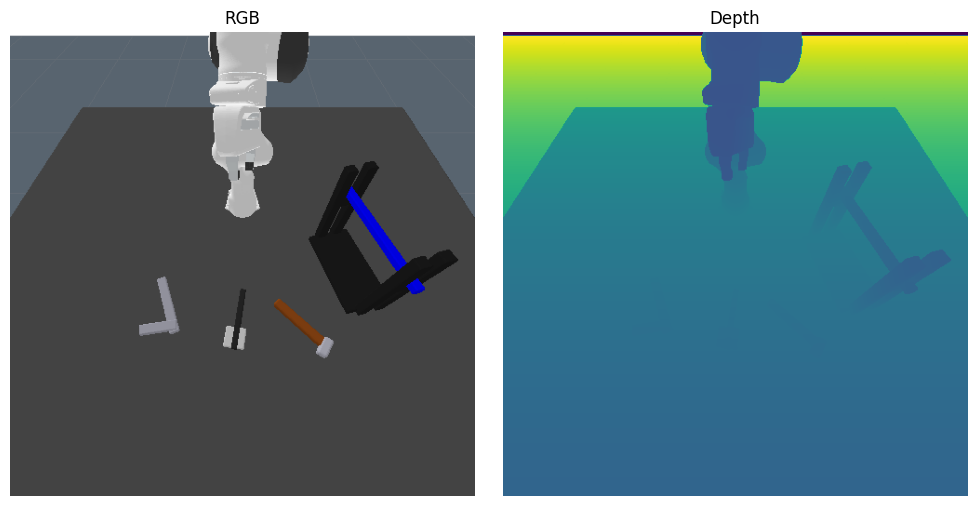


Trial 0 | Calling OpenAI...
Asking for tool selection and all waypoints together...

Final predicted data:
{
  "selected_tool": "spatula",
  "selection_reasoning": "The spatula is best because its thin, flat blade can slide underneath the blue cylindrical stick more reliably than the hammer or L-ruler. That broad underside support makes it better for a stable upward lift from below.",
  "tool_waypoint": {
    "camera_uv": [
      269,
      357
    ]
  },
  "initial_waypoint": {
    "camera_uv": [
      398,
      283
    ]
  },
  "goal_waypoint": {
    "camera_uv": [
      395,
      225
    ]
  }
}


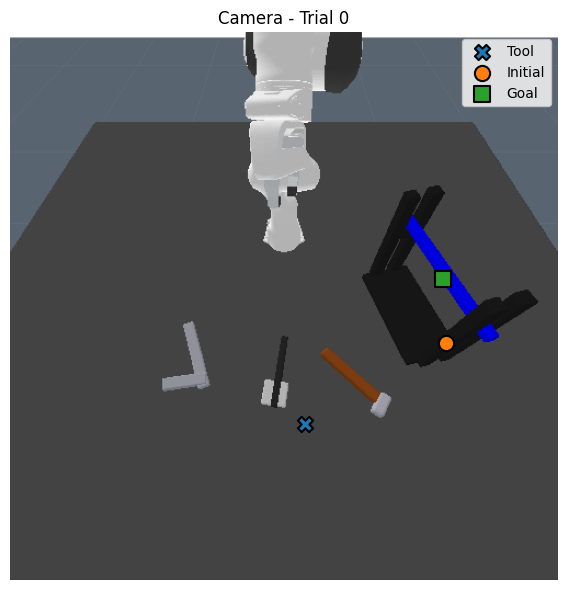

Saved: test_runs/2026-04-07_16-17-08/trial_000_waypoints.png
pcl size main: (500, 500, 3)
(500, 500, 3)
point:  [0.06678833 0.37612376 0.87879384]
camera position: [0.  0.7 1.6]
camera rotation matrix:
 [[-1.00000000e+00 -1.22464680e-16  0.00000000e+00]
 [-1.06057524e-16  8.66025404e-01 -5.00000000e-01]
 [ 6.12323400e-17 -5.00000000e-01 -8.66025404e-01]]
(500, 500, 3)
point:  [0.06678833 0.37612376 0.87879384]
tool point world: [-0.06582572  0.58797404  0.66455988]
initial point world: [-0.26397122  0.52802425  1.18441236]
goal point world: [-0.44383035  0.25111723  0.97555718]
selected tool: spatula
selected tool by point cloud:  spatula
selected tool base:  spatula-base
Grasp Score: 0.0
Task Score: 0.10586000752687066
All Score: 0.10586000752687066
-- bot.cpp:~BotOp:135(0) shutting down BotOp...
-- simulation.cpp:~BotThreadedSim:57(0) shutting down SimThread
-- simulation.cpp:~Simulation:148(0) shutting down Simulation
{'name': 'table', 'ID': 1, 'rel': [0.0, 0.0, 0.6, 1.0, 0.0, 0.0, 

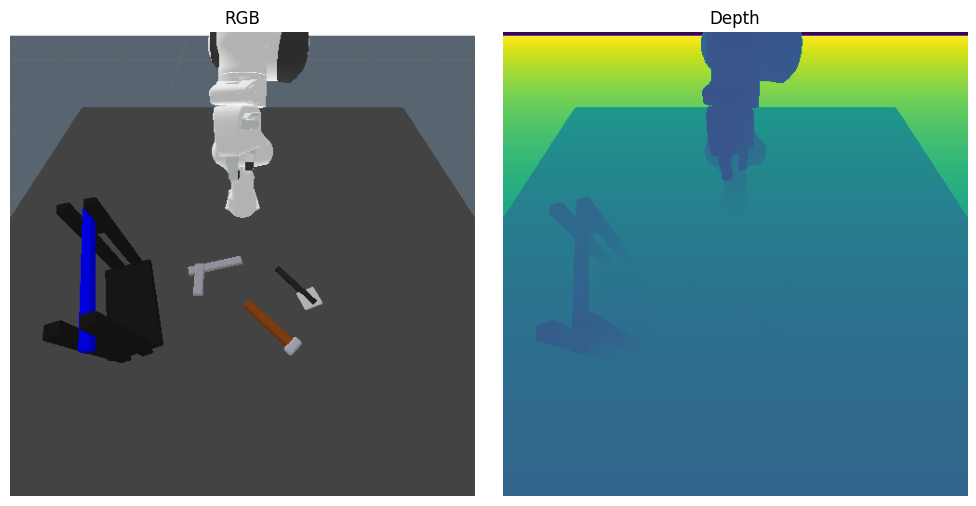


Trial 1 | Calling OpenAI...
Asking for tool selection and all waypoints together...

Final predicted data:
{
  "selected_tool": "spatula",
  "selection_reasoning": "The spatula is best because its thin, flat blade can slide underneath the blue cylindrical stick and support it from below for a stable lift. The hammer and L-ruler are less suitable for getting securely under the stick's underside.",
  "tool_waypoint": {
    "camera_uv": [
      317,
      259
    ]
  },
  "initial_waypoint": {
    "camera_uv": [
      88,
      319
    ]
  },
  "goal_waypoint": {
    "camera_uv": [
      88,
      246
    ]
  }
}


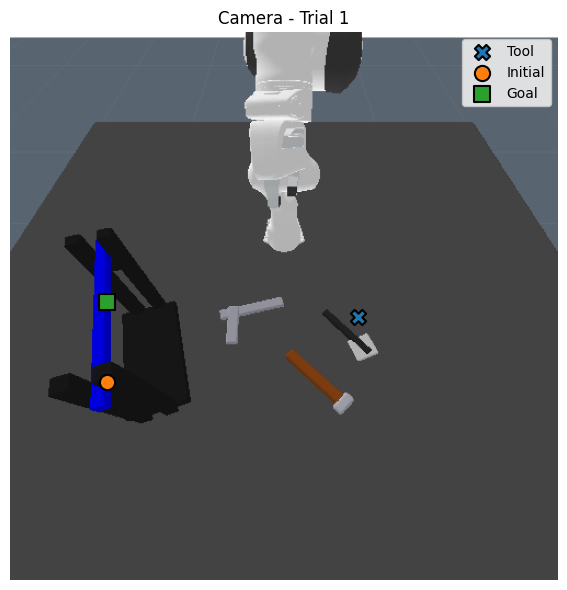

Saved: test_runs/2026-04-07_16-17-08/trial_001_waypoints.png
pcl size main: (500, 500, 3)
(500, 500, 3)
point:  [0.28767478 0.03864288 1.07341337]
camera position: [0.  0.7 1.6]
camera rotation matrix:
 [[-1.00000000e+00 -1.22464680e-16  0.00000000e+00]
 [-1.06057524e-16  8.66025404e-01 -5.00000000e-01]
 [ 6.12323400e-17 -5.00000000e-01 -8.66025404e-01]]
(500, 500, 3)
point:  [0.28767478 0.03864288 1.07341337]
tool point world: [-0.28365461  0.20379169  0.66433628]
initial point world: [0.29225053 0.58229836 1.14718062]
goal point world: [0.44884462 0.34407148 1.00567888]
selected tool: spatula
selected tool by point cloud:  spatula
selected tool base:  spatula-base
I added the joint to the base.
Grasp Score: 0.0
Task Score: 0.11037039241910988
All Score: 0.11037039241910988
-- bot.cpp:~BotOp:135(0) shutting down BotOp...
-- simulation.cpp:~BotThreadedSim:57(0) shutting down SimThread
-- simulation.cpp:~Simulation:148(0) shutting down Simulation
{'name': 'table', 'ID': 1, 'rel': [0.0, 

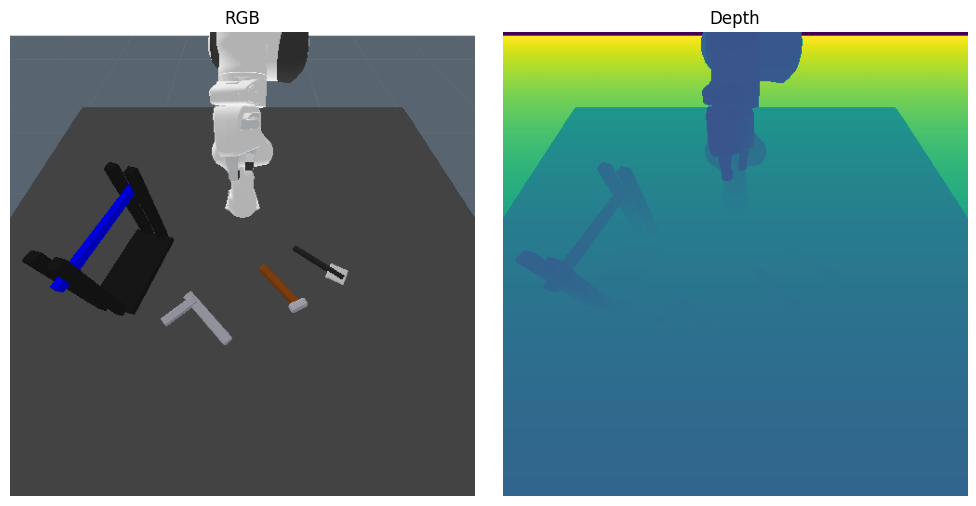


Trial 2 | Calling OpenAI...
Asking for tool selection and all waypoints together...

Final predicted data:
{
  "selected_tool": "spatula",
  "selection_reasoning": "The spatula is best for this task because its thin, flat blade can slide underneath the blue cylindrical stick more reliably than the hammer or L-ruler. That broad underside support makes it the most stable option for lifting the stick upward from below.",
  "tool_waypoint": {
    "camera_uv": [
      299,
      328
    ]
  },
  "initial_waypoint": {
    "camera_uv": [
      67,
      274
    ]
  },
  "goal_waypoint": {
    "camera_uv": [
      67,
      214
    ]
  }
}


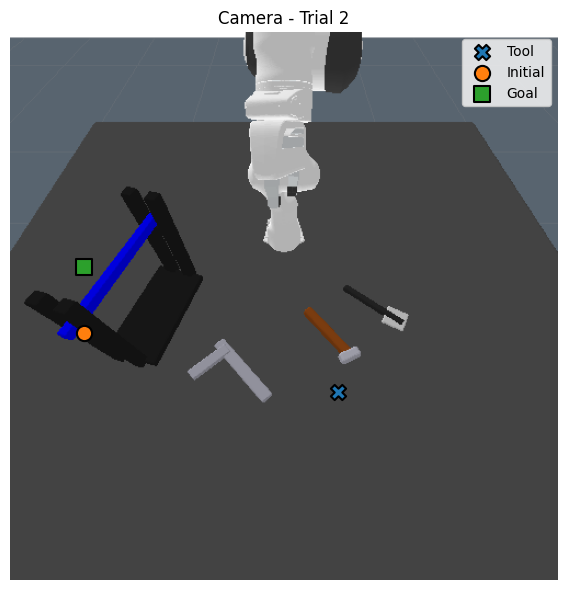

Saved: test_runs/2026-04-07_16-17-08/trial_002_waypoints.png
pcl size main: (500, 500, 3)
(500, 500, 3)
point:  [0.18200889 0.28972846 0.92861682]
camera position: [0.  0.7 1.6]
camera rotation matrix:
 [[-1.00000000e+00 -1.22464680e-16  0.00000000e+00]
 [-1.06057524e-16  8.66025404e-01 -5.00000000e-01]
 [ 6.12323400e-17 -5.00000000e-01 -8.66025404e-01]]
(500, 500, 3)
point:  [0.18200889 0.28972846 0.92861682]
tool point world: [-0.17864843  0.49054376  0.66845288]
initial point world: [0.3192095  0.51821561 1.20141313]
goal point world: [0.56199656 0.22037765 0.99038313]
selected tool: spatula
selected tool by point cloud:  hammer
selected tool base:  hammer-base
I added the joint to the base.
Grasp Score: 0.0
Task Score: 0.1716726846608656
All Score: 0.1716726846608656
-- bot.cpp:~BotOp:135(0) shutting down BotOp...
-- simulation.cpp:~BotThreadedSim:57(0) shutting down SimThread
-- simulation.cpp:~Simulation:148(0) shutting down Simulation
{'name': 'table', 'ID': 1, 'rel': [0.0, 0.0,

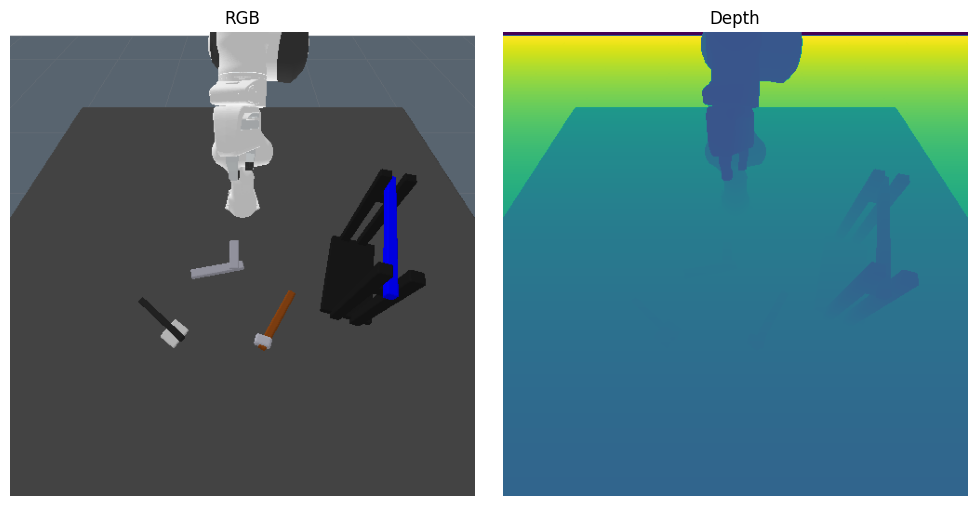


Trial 3 | Calling OpenAI...
Asking for tool selection and all waypoints together...

Final predicted data:
{
  "selected_tool": "spatula",
  "selection_reasoning": "The spatula is best because its broad, flat blade can slide underneath the blue cylindrical stick and support it from below during an upward lift. The hammer and L-ruler are less stable for wedging under the stick's center of mass.",
  "tool_waypoint": {
    "camera_uv": [
      296,
      308
    ]
  },
  "initial_waypoint": {
    "camera_uv": [
      405,
      286
    ]
  },
  "goal_waypoint": {
    "camera_uv": [
      404,
      221
    ]
  }
}


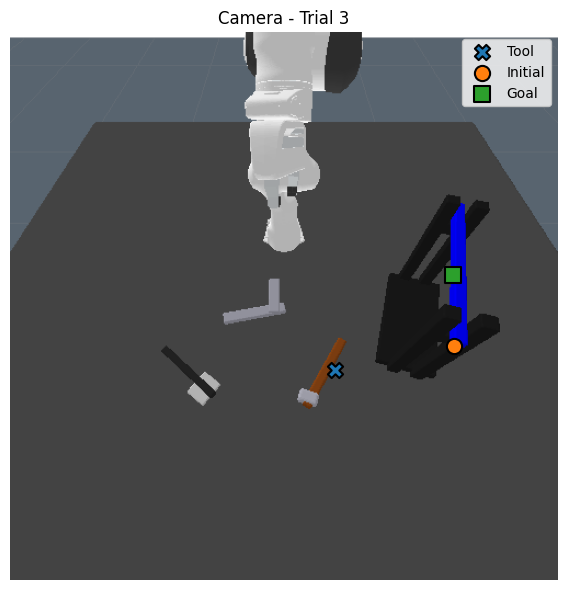

Saved: test_runs/2026-04-07_16-17-08/trial_003_waypoints.png
pcl size main: (500, 500, 3)
(500, 500, 3)
point:  [0.17781781 0.22420506 0.96640116]
camera position: [0.  0.7 1.6]
camera rotation matrix:
 [[-1.00000000e+00 -1.22464680e-16  0.00000000e+00]
 [-1.06057524e-16  8.66025404e-01 -5.00000000e-01]
 [ 6.12323400e-17 -5.00000000e-01 -8.66025404e-01]]
(500, 500, 3)
point:  [0.17781781 0.22420506 0.96640116]
tool point world: [-0.17463391  0.41614196  0.66796229]
initial point world: [-0.26227657  0.54124131  1.20319019]
goal point world: [-0.43778117  0.27326361  1.02574951]
selected tool: spatula
selected tool by point cloud:  hammer
selected tool base:  hammer-base
I added the joint to the base.
Grasp Score: 0.0
Task Score: 0.03163433411908142
All Score: 0.03163433411908142
-- bot.cpp:~BotOp:135(0) shutting down BotOp...
-- simulation.cpp:~BotThreadedSim:57(0) shutting down SimThread
-- simulation.cpp:~Simulation:148(0) shutting down Simulation
{'name': 'table', 'ID': 1, 'rel': [0

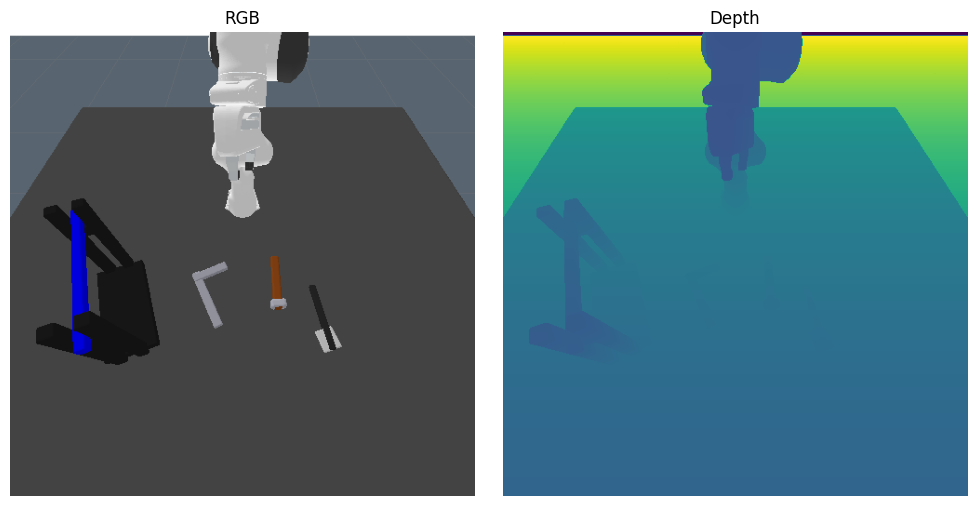


Trial 4 | Calling OpenAI...
Asking for tool selection and all waypoints together...

Final predicted data:
{
  "selected_tool": "spatula",
  "selection_reasoning": "The spatula is best for this task because its thin, flat blade can slide underneath the blue cylindrical stick and support it during an upward lift. The hammer is bulky and the L-ruler is better for hooking than for stable under-support.",
  "tool_waypoint": {
    "camera_uv": [
      367,
      300
    ]
  },
  "initial_waypoint": {
    "camera_uv": [
      60,
      338
    ]
  },
  "goal_waypoint": {
    "camera_uv": [
      60,
      270
    ]
  }
}


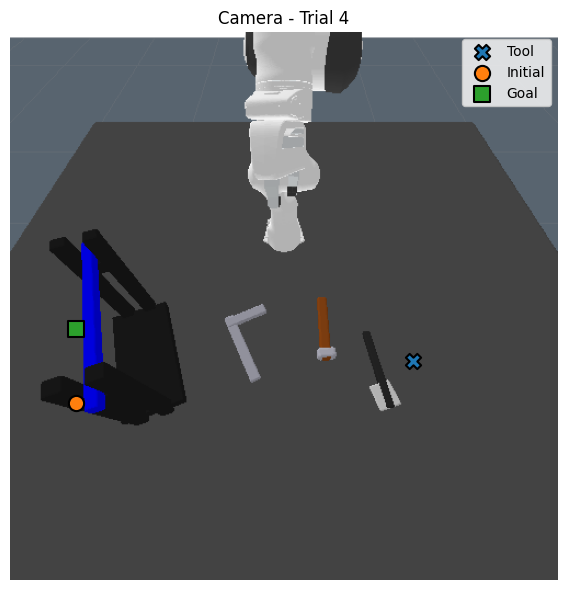

Saved: test_runs/2026-04-07_16-17-08/trial_004_waypoints.png
pcl size main: (500, 500, 3)
(500, 500, 3)
point:  [0.45975909 0.19647825 0.98239124]
camera position: [0.  0.7 1.6]
camera rotation matrix:
 [[-1.00000000e+00 -1.22464680e-16  0.00000000e+00]
 [-1.06057524e-16  8.66025404e-01 -5.00000000e-01]
 [ 6.12323400e-17 -5.00000000e-01 -8.66025404e-01]]
(500, 500, 3)
point:  [0.45975909 0.19647825 0.98239124]
tool point world: [-0.45312881  0.38358933  0.66467107]
initial point world: [0.31186333 0.61991717 1.17240854]
goal point world: [0.49573473 0.41905019 1.00901545]
selected tool: spatula
selected tool by point cloud:  spatula
selected tool base:  spatula-base
Grasp Score: 0.0
Task Score: 0.013394887230482464
All Score: 0.013394887230482464
-- bot.cpp:~BotOp:135(0) shutting down BotOp...
-- simulation.cpp:~BotThreadedSim:57(0) shutting down SimThread
{'name': 'table', 'ID': 1, 'rel': [0.0, 0.0, 0.6, 1.0, 0.0, 0.0, 0.0], 'shape': 'ssBox', 'size': [2.5, 2.5, 0.1, 0.02], 'color': [0

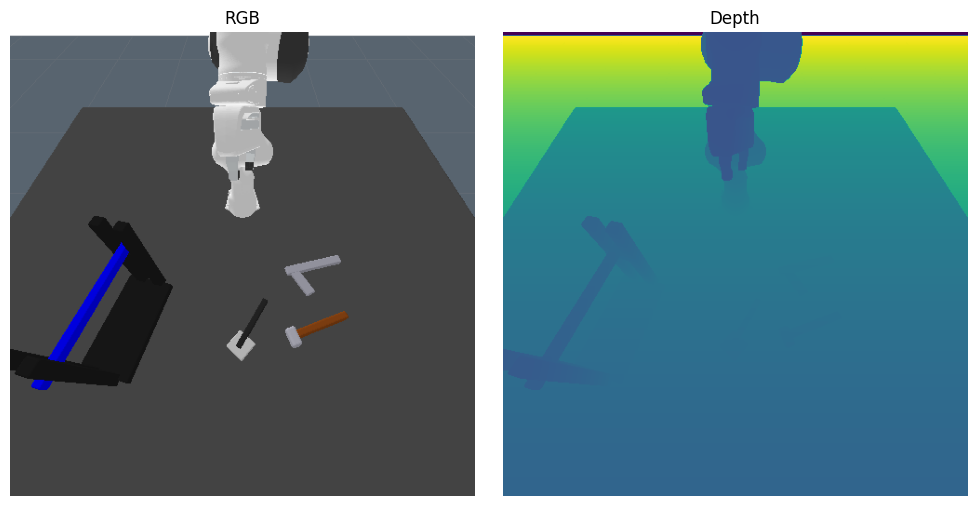


Trial 5 | Calling OpenAI...
Asking for tool selection and all waypoints together...

Final predicted data:
{
  "selected_tool": "spatula",
  "selection_reasoning": "The spatula is best because its thin, flat blade can slide underneath the blue cylindrical stick and support it from below for a stable lift. The hammer is poor for wedging under the stick, and the L-ruler is better for hooking than for secure underside support.",
  "tool_waypoint": {
    "camera_uv": [
      336,
      345
    ]
  },
  "initial_waypoint": {
    "camera_uv": [
      58,
      348
    ]
  },
  "goal_waypoint": {
    "camera_uv": [
      60,
      292
    ]
  }
}


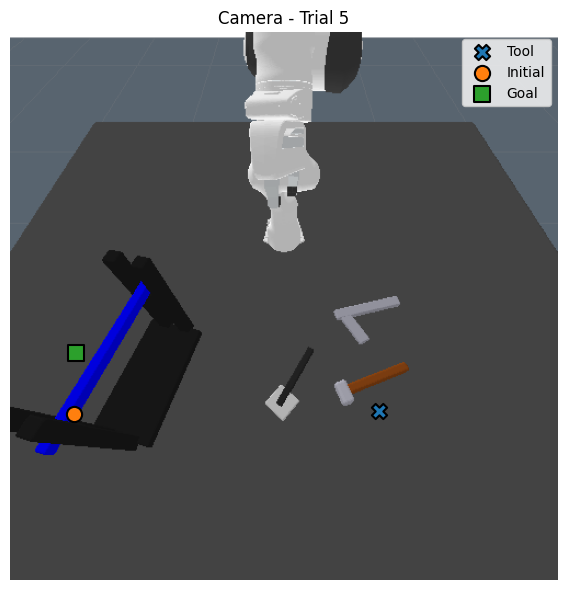

Saved: test_runs/2026-04-07_16-17-08/trial_005_waypoints.png
pcl size main: (500, 500, 3)
(500, 500, 3)
point:  [0.30916917 0.34152406 0.89874756]
camera position: [0.  0.7 1.6]
camera rotation matrix:
 [[-1.00000000e+00 -1.22464680e-16  0.00000000e+00]
 [-1.06057524e-16  8.66025404e-01 -5.00000000e-01]
 [ 6.12323400e-17 -5.00000000e-01 -8.66025404e-01]]
(500, 500, 3)
point:  [0.30916917 0.34152406 0.89874756]
tool point world: [-0.30342308  0.54924958  0.66853932]
initial point world: [0.33747639 0.62946478 1.13332226]
goal point world: [0.50842843 0.46283972 0.96444747]
selected tool: spatula
selected tool by point cloud:  hammer
selected tool base:  hammer-base
I added the joint to the base.
Grasp Score: 0.0
Task Score: 0.12586828847240047
All Score: 0.12586828847240047
-- bot.cpp:~BotOp:135(0) shutting down BotOp...
-- simulation.cpp:~BotThreadedSim:57(0) shutting down SimThread
-- simulation.cpp:~Simulation:148(0) shutting down Simulation
{'name': 'table', 'ID': 1, 'rel': [0.0, 0.

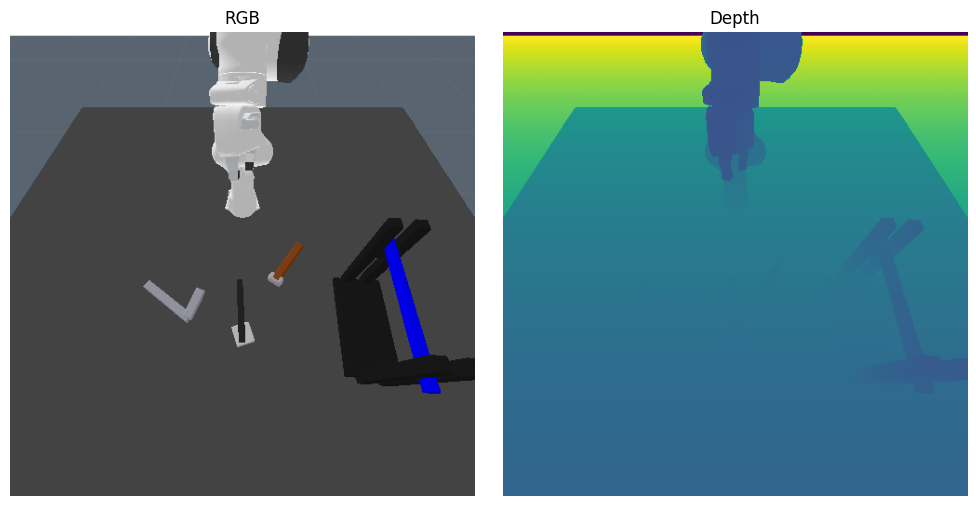


Trial 6 | Calling OpenAI...
Asking for tool selection and all waypoints together...

Final predicted data:
{
  "selected_tool": "spatula",
  "selection_reasoning": "The spatula is best because its thin, flat blade can slide under the blue cylindrical stick more reliably than the hammer or L-ruler. This shape provides a broader supporting surface for a stable upward lift from below.",
  "tool_waypoint": {
    "camera_uv": [
      246,
      345
    ]
  },
  "initial_waypoint": {
    "camera_uv": [
      430,
      390
    ]
  },
  "goal_waypoint": {
    "camera_uv": [
      426,
      325
    ]
  }
}


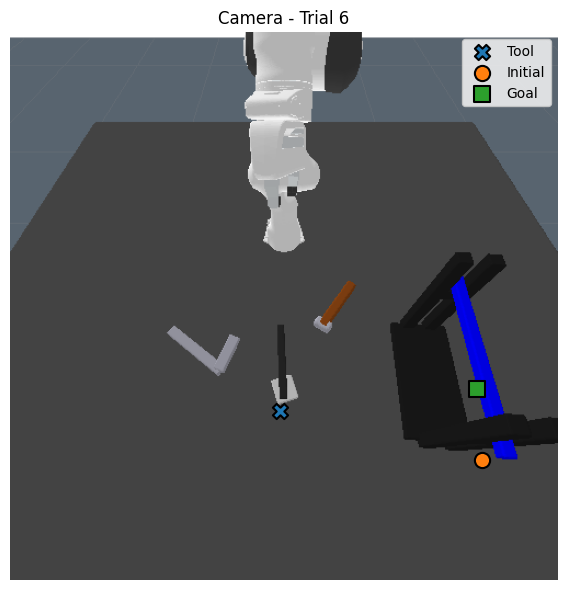

Saved: test_runs/2026-04-07_16-17-08/trial_006_waypoints.png
pcl size main: (500, 500, 3)
(500, 500, 3)
point:  [-0.01437996  0.34152406  0.89874756]
camera position: [0.  0.7 1.6]
camera rotation matrix:
 [[-1.00000000e+00 -1.22464680e-16  0.00000000e+00]
 [-1.06057524e-16  8.66025404e-01 -5.00000000e-01]
 [ 6.12323400e-17 -5.00000000e-01 -8.66025404e-01]]
(500, 500, 3)
point:  [-0.01437996  0.34152406  0.89874756]
tool point world: [0.01421289 0.54817938 0.6619267 ]
initial point world: [-0.24206563  0.6949483   1.21470366]
goal point world: [-0.38918557  0.56721675  1.03832041]
selected tool: spatula
selected tool by point cloud:  spatula
selected tool base:  spatula-base
Grasp Score: 1.4360787039829468e-15
Task Score: 0.18724036099939545
All Score: 0.1872403609993969
-- bot.cpp:~BotOp:135(0) shutting down BotOp...
-- simulation.cpp:~BotThreadedSim:57(0) shutting down SimThread
-- simulation.cpp:~Simulation:148(0) shutting down Simulation
{'name': 'table', 'ID': 1, 'rel': [0.0, 0.0,

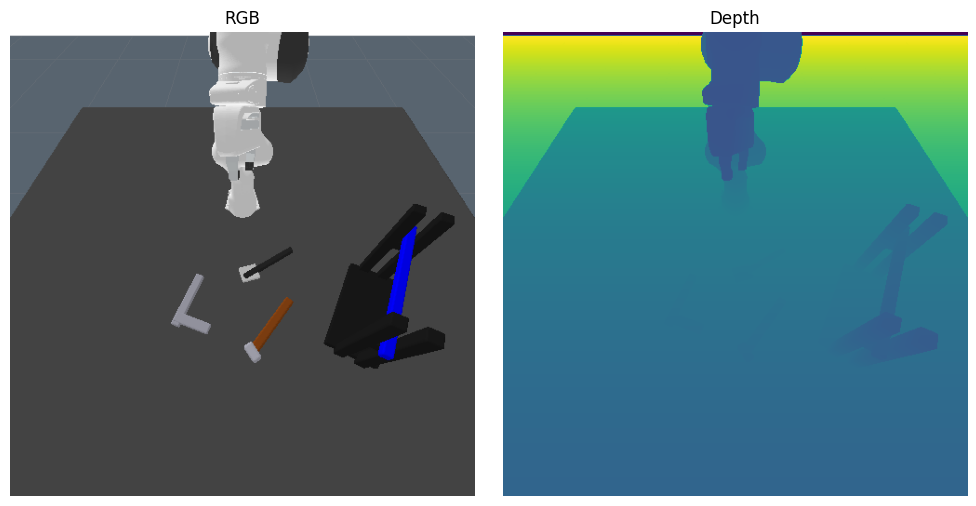


Trial 7 | Calling OpenAI...
Asking for tool selection and all waypoints together...

Final predicted data:
{
  "selected_tool": "spatula",
  "selection_reasoning": "The spatula is best because its broad, flat blade can slide underneath the blue cylindrical stick and support it from below during an upward lift. The hammer and L-ruler are less stable for wedging under the stick's center of mass.",
  "tool_waypoint": {
    "camera_uv": [
      281,
      332
    ]
  },
  "initial_waypoint": {
    "camera_uv": [
      424,
      313
    ]
  },
  "goal_waypoint": {
    "camera_uv": [
      424,
      250
    ]
  }
}


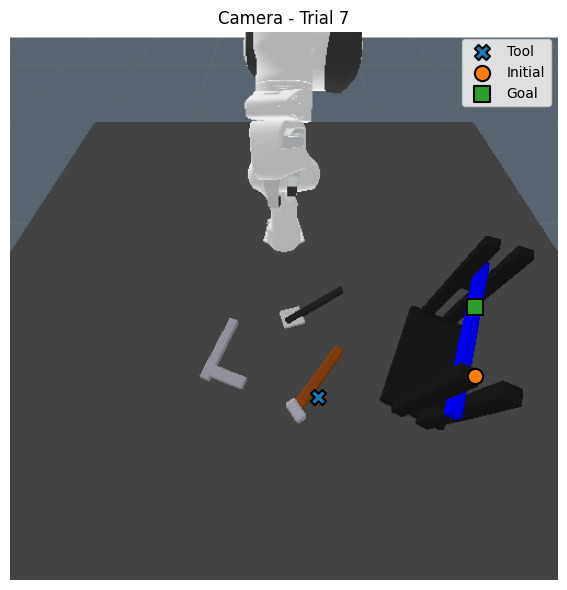

Saved: test_runs/2026-04-07_16-17-08/trial_007_waypoints.png
pcl size main: (500, 500, 3)
(500, 500, 3)
point:  [0.11425499 0.30222288 0.92141122]
camera position: [0.  0.7 1.6]
camera rotation matrix:
 [[-1.00000000e+00 -1.22464680e-16  0.00000000e+00]
 [-1.06057524e-16  8.66025404e-01 -5.00000000e-01]
 [ 6.12323400e-17 -5.00000000e-01 -8.66025404e-01]]
(500, 500, 3)
point:  [0.11425499 0.30222288 0.92141122]
tool point world: [-0.11235055  0.50434363  0.66674257]
initial point world: [-0.40040182  0.53790538  1.02929773]
goal point world: [-0.49344959  0.34551035  0.98600592]
selected tool: spatula
selected tool by point cloud:  hammer
selected tool base:  hammer-base
I added the joint to the base.
Grasp Score: 0.0
Task Score: 0.18810171404398873
All Score: 0.18810171404398873
-- bot.cpp:~BotOp:135(0) shutting down BotOp...
-- simulation.cpp:~BotThreadedSim:57(0) shutting down SimThread
-- simulation.cpp:~Simulation:148(0) shutting down Simulation
{'name': 'table', 'ID': 1, 'rel': [0

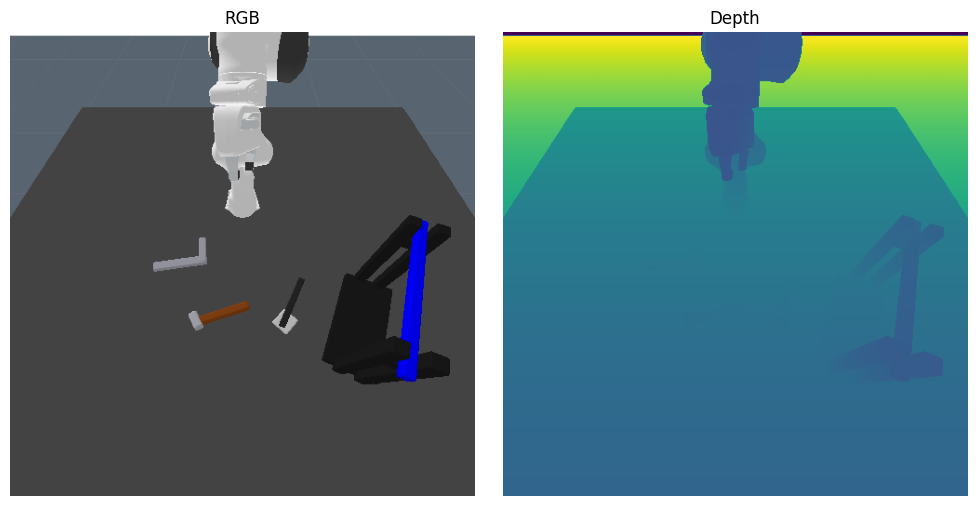


Trial 8 | Calling OpenAI...
Asking for tool selection and all waypoints together...

Final predicted data:
{
  "selected_tool": "spatula",
  "selection_reasoning": "The spatula is best because its thin, flat blade can slide underneath the blue cylindrical stick more easily than the hammer or L-ruler. That broad flat end provides a more stable support surface for lifting the stick upward from below.",
  "tool_waypoint": {
    "camera_uv": [
      276,
      300
    ]
  },
  "initial_waypoint": {
    "camera_uv": [
      433,
      349
    ]
  },
  "goal_waypoint": {
    "camera_uv": [
      432,
      276
    ]
  }
}


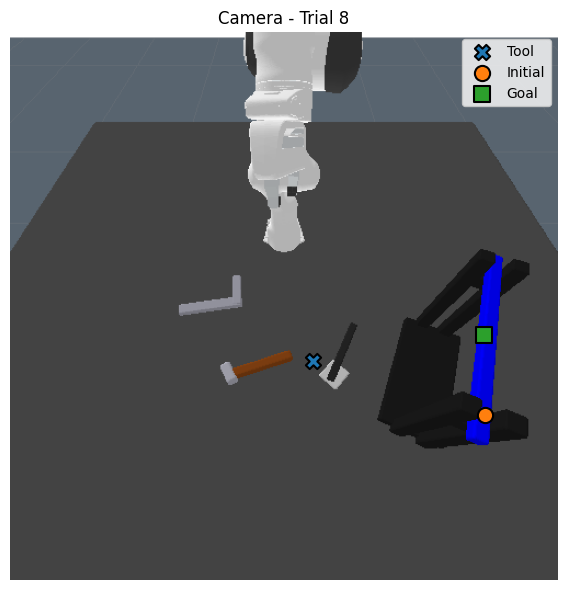

Saved: test_runs/2026-04-07_16-17-08/trial_008_waypoints.png
pcl size main: (500, 500, 3)
(500, 500, 3)
point:  [0.10216869 0.19647825 0.98239124]
camera position: [0.  0.7 1.6]
camera rotation matrix:
 [[-1.00000000e+00 -1.22464680e-16  0.00000000e+00]
 [-1.06057524e-16  8.66025404e-01 -5.00000000e-01]
 [ 6.12323400e-17 -5.00000000e-01 -8.66025404e-01]]
(500, 500, 3)
point:  [0.10216869 0.19647825 0.98239124]
tool point world: [-0.10083571  0.38314809  0.66336674]
initial point world: [-0.29602343  0.63648682  1.16970431]
goal point world: [-0.46332479  0.439104    1.01573636]
selected tool: spatula
selected tool by point cloud:  spatula
selected tool base:  spatula-base
Grasp Score: 0.0
Task Score: -0.2105407465849251
All Score: -0.2105407465849251
-- bot.cpp:~BotOp:135(0) shutting down BotOp...
-- simulation.cpp:~BotThreadedSim:57(0) shutting down SimThread
-- simulation.cpp:~Simulation:148(0) shutting down Simulation
{'name': 'table', 'ID': 1, 'rel': [0.0, 0.0, 0.6, 1.0, 0.0, 0.0, 

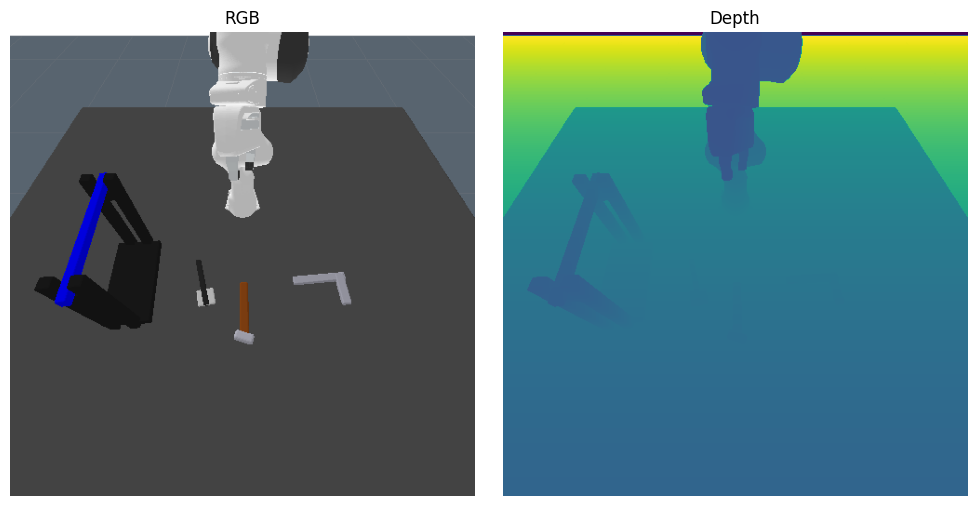


Trial 9 | Calling OpenAI...
Asking for tool selection and all waypoints together...

Final predicted data:
{
  "selected_tool": "spatula",
  "selection_reasoning": "The spatula is best for this task because its thin, flat blade can slide underneath the blue cylindrical stick and support it from below during a lift. The hammer and L-ruler are less stable for wedging under the stick's underside and could slip during upward motion.",
  "tool_waypoint": {
    "camera_uv": [
      254,
      309
    ]
  },
  "initial_waypoint": {
    "camera_uv": [
      67,
      289
    ]
  },
  "goal_waypoint": {
    "camera_uv": [
      69,
      228
    ]
  }
}


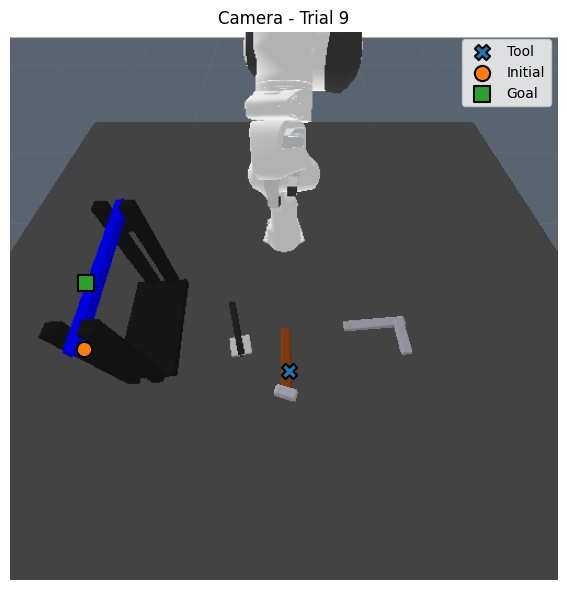

Saved: test_runs/2026-04-07_16-17-08/trial_009_waypoints.png
pcl size main: (500, 500, 3)
(500, 500, 3)
point:  [0.01490808 0.21989411 0.93175471]
camera position: [0.  0.7 1.6]
camera rotation matrix:
 [[-1.00000000e+00 -1.22464680e-16  0.00000000e+00]
 [-1.06057524e-16  8.66025404e-01 -5.00000000e-01]
 [ 6.12323400e-17 -5.00000000e-01 -8.66025404e-01]]
(500, 500, 3)
point:  [0.01490808 0.21989411 0.93175471]
tool point world: [-0.01518501  0.41943991  0.66609797]
initial point world: [0.28356927 0.55864148 1.23429427]
goal point world: [0.47522439 0.32178293 1.06043298]
selected tool: spatula
selected tool by point cloud:  hammer
selected tool base:  hammer-base
I added the joint to the base.
Grasp Score: 0.0
Task Score: 0.08883271902416441
All Score: 0.08883271902416441

 VLM vs. Spatial Point Cloud Evaluation Results

--- Total Selections ---
VLM Text Predictions:
  - hammer: 0
  - L-ruler: 0
  - spatula: 10

Spatial Point Cloud Corrections:
  - hammer: 5
  - L-ruler: 0
  - spatula

In [12]:
run_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
save_dir = Path("test_runs") / run_time
save_dir.mkdir(parents=True, exist_ok=True)

print("Saving to:", save_dir)
trial = 0

evaluation_stats = {
    "vlm_selected": {"hammer": 0, "L-ruler": 0, "spatula": 0},
    "pc_selected": {"hammer": 0, "L-ruler": 0, "spatula": 0},
    "total_mismatches": 0,
    "mismatch_log": []  # To store the exact details of what went wrong
}

while trial < parameters["num-trials"]:
    try:
        environment = GenerateEnvironment(parameters)
        environment.generate_environment()
        environment.C.delFrame("pcl")
        environment.C.view()
        # print(environment.C.getFrameNames())
        # cam = ry.CameraView(environment.C)
        # cam.setCamera("camera5")
        # print(cam.getFxycxy())
        # print(environment.C.getFrame('l_panda_base').getPosition())
        # print(environment.C.getFrame('camera5').getPosition())
        # print(environment.C.getFrame('camera5').getRotationMatrix())
        # raise Exception
    

        rgb_images, depth_images, pcls = mutils.get_rgb_images(environment.C, parameters["cameras"], environment.C.getFrame("camera5"))
        # f = environment.C.addFrame('pcl', 'world')
        # f.setPointCloud(points= pcls[0], colors = [0,0,255])
        print("RGB shape:", rgb_images[0].shape)
        print("Depth shape:", depth_images[0].  shape )
        print("Point cloud shape:", pcls[0      ].shape)
        draw_rgb_and_depth(rgb_images[0], depth_images[0])
        environment.C.view()

        

        image_bytes = numpy_to_bytes(rgb_images[0], (500, 500))

        if parameters["task"] == "minigolf":
            task_name = "Precision Minigolf: Tool-Assisted Ball Striking"
            # task_description = "Use the tool to push the ball into the hole on the platform."
            task_description = "The objective is to use a tool to perform a controlled push of a blue spherical ball into a white target hole located on a raised black rectangular platform."
        elif parameters["task"] == "lifting":
            task_description = "The objective is to use a tool to securely lift a blue cylindrical stick from its starting position on the target platform. The robot must wedge or slide the tool under the stick to ensure a stable upward relocation."
            task_name = "Tool-Assisted Stable Lifting"

        else:
            raise Exception("Unknown task")
        

        print(f"\nTrial {trial} | Calling OpenAI...")


        print("Asking for tool selection and all waypoints together...")

        raw_resp = ask_openai_with_image(
            get_prompt_detailed(parameters["task"], task_description),
            image_bytes
        )

        final_predicted_data = extract_json(raw_resp)

        print("\nFinal predicted data:")
        print(json.dumps(final_predicted_data, indent=2))

        visualize_predicted_waypoints(
            rgb_images,
            final_predicted_data,
            trial,
            save_dir,
            vlm_size=500
            )
        print(f"pcl size main: {pcls[0].shape}")
        tool_point = get_point_from_pcl(final_predicted_data, pcls, "tool_waypoint")
        lifting_obj = environment.C.getFrame("lifting-obj").getPosition()
        # init_point = get_world_from_pixel(environment, final_predicted_data["initial_waypoint"]["camera_uv"], lifting_obj[2] - 0.1)
        # goal_point = get_world_from_pixel(environment, final_predicted_data["goal_waypoint"]["camera_uv"], lifting_obj[2] + 0.1)
        # init_point = get_point_from_pcl(final_predicted_data, pcls, "initial_waypoint")
        # goal_point = get_point_from_pcl(final_predicted_data, pcls, "goal_waypoint")

        # print("tool point:", tool_point)
        # print("init point:", init_point)
        # print("goal point:", goal_point)

        cam_frame = environment.C.getFrame("camera5")
        print("camera position:", cam_frame.getPosition())
        print("camera rotation matrix:\n", cam_frame.getRotationMatrix())

        # ball_frame = environment.C.getFrame("minigolf-obj")
        # print("ball world position:", ball_frame.getPosition())

        tool_point_cam, tool_point_world = get_world_point(final_predicted_data, pcls, cam_frame, "tool_waypoint")
        selected_tool_pc = find_selected_tool_by_pc(environment, tool_point_world)

        # tool_point_cam, tool_point_world = get_world_point(final_predicted_data, pcls, cam_frame, "tool_waypoint")
        tool_point_world = get_world_from_pixel(environment, final_predicted_data["tool_waypoint"]["camera_uv"], environment.C.getFrame(selected_tool_pc+"-base").getPosition()[2])

        init_point_world = get_world_from_pixel_with_perpendicular_lift(environment, final_predicted_data["initial_waypoint"]["camera_uv"])
        goal_point_world = get_world_from_pixel_with_perpendicular_lift(environment, final_predicted_data["goal_waypoint"]["camera_uv"])
        
        # init_point_world = get_world_from_pixel(environment, final_predicted_data["initial_waypoint"]["camera_uv"], init_target)
        # goal_point_world = get_world_from_pixel(environment, final_predicted_data["goal_waypoint"]["camera_uv"], goal_target)
        # init_point_cam, init_point_world = get_world_point(final_predicted_data, pcls, cam_frame, "initial_waypoint")
        # goal_point_cam, goal_point_world = get_world_point(final_predicted_data, pcls, cam_frame, "goal_waypoint")

       
        # print("tool point camera:", tool_point_cam)
        print("tool point world:", tool_point_world)

        # print("initial point camera:", init_point_cam)
        print("initial point world:", init_point_world)

        # print("goal point camera:", goal_point_cam)
        print("goal point world:", goal_point_world)

        print("selected tool:", final_predicted_data["selected_tool"])


        
        # print(f"Selected tool center: {environment.C.getFrame(best_tool + '-head').getPosition()}")
        # print(f"Selected tool center: {tool_point_world}")
        # 
        if final_predicted_data["selected_tool"] == "hammer":
            tool_label = 3
        elif final_predicted_data["selected_tool"] == "spatula":
            tool_label = 4
        elif final_predicted_data["selected_tool"] == "L-ruler":
            tool_label = 5
        
        tool_mask = np.isin(environment.point_clouds_labels[:,3], tool_label)
        tool_pc = environment.point_clouds_labels[tool_mask]
        f = environment.C.addFrame('tool-pcl', 'world')
        f.setPointCloud(points= tool_pc[:,:3], colors = [0,0,255])
        environment.C.view()

        # grasp_position = mutils.post_posititon(tool_pc[:,:3], tool_point_world)
        grasp_position = tool_point_world   
        selected_tool_pc = find_selected_tool_by_pc(environment, tool_point_world)
        print("selected tool by point cloud: ", selected_tool_pc)
        selected_tool_base = selected_tool_pc + "-base"
        print("selected tool base: ", selected_tool_base)

        grasp_position[2] = environment.C.getFrame(selected_tool_pc+'-base').getPosition()[2] - 0.01
        # init_point_world[2] = init_point_world[2] - 0.1
        # goal_point_world[2] = environment.C.getFrame("lifting-obj").getPosition()[2]
        
        
        if environment.C.getFrame("lifting-obj").getPosition()[0] < 0: 
            init_point_world[0] = init_point_world[0] + 0.15
        else: 
            init_point_world[0] = init_point_world[0] - 0.15


        environment.C.addFrame("tool-waypoint") \
            .setShape(ry.ST.marker, [0.1]) \
            .setPosition(grasp_position)

        environment.C.addFrame("initial-waypoint") \
            .setShape(ry.ST.marker, [0.1]) \
            .setPosition(init_point_world)

        environment.C.addFrame("goal-waypoint") \
            .setShape(ry.ST.marker, [0.1]) \
            .setPosition(goal_point_world)
        
        environment.C.view()

        best_tool = final_predicted_data["selected_tool"]
        selected_part = mutils.find_grasping_part(
                environment.C,
                selected_tool_pc,
                tool_point_world
            )
        other_tools = [item for item in environment.tool_objs if item != selected_tool_pc]
        mutils.reparent_tool(environment.C, best_tool, selected_part, other_tools)

        

        environment.C.getFrame("tool-waypoint").setQuaternion(environment.C.getFrame(selected_part).getQuaternion())
        # environment.C.getFrame("initial-waypoint").setQuaternion(environment.C.getFrame(selected_part).getQuaternion())
        # environment.C.getFrame("goal-waypoint").setQuaternion(environment.C.getFrame(selected_part).getQuaternion())
        
        environment.C.getFrame("initial-waypoint").setQuaternion(mutils.rotate_quat_yaw_angle(environment.C.getFrame("lifting-platform").getQuaternion(),-90))
        environment.C.getFrame("goal-waypoint").setQuaternion(mutils.rotate_quat_yaw_angle(environment.C.getFrame("lifting-platform").getQuaternion(),-90))

        mutils.ManipulationWithKOMO_lifting(environment.C, best_tool, environment.env)


        vlm_tool = final_predicted_data["selected_tool"]
        pc_tool = selected_tool_pc

        if vlm_tool in evaluation_stats["vlm_selected"]:
            evaluation_stats["vlm_selected"][vlm_tool] += 1
        else:
            print("Unknown VLM tool:", vlm_tool)

        if pc_tool in evaluation_stats["pc_selected"]:
            evaluation_stats["pc_selected"][pc_tool] += 1

        # 4. Check for and log any mismatches
        if vlm_tool != pc_tool:
            evaluation_stats["total_mismatches"] += 1
            evaluation_stats["mismatch_log"].append({
                "vlm_text_prediction": vlm_tool,
                "pc_spatial_correction": pc_tool
            })


        trial += 1

    except PlacementError as e:
        print("PlacementError:", e)
        print("Retrying trial...")
    except Exception as e:
        print("Exception occurred:")
        traceback.print_exc()
        break
    
print("\n" + "="*50)
print(" VLM vs. Spatial Point Cloud Evaluation Results")
print("="*50)

# Print the overall counts
print("\n--- Total Selections ---")
print("VLM Text Predictions:")
for tool, count in evaluation_stats["vlm_selected"].items():
    print(f"  - {tool}: {count}")

print("\nSpatial Point Cloud Corrections:")
for tool, count in evaluation_stats["pc_selected"].items():
    print(f"  - {tool}: {count}")

# Print the mismatch details
print("\n--- Mismatch Summary ---")
print(f"Total Mismatches: {evaluation_stats['total_mismatches']}")

if evaluation_stats["total_mismatches"] > 0:
    print("\nDetailed Mismatch Log:")
    for idx, mismatch in enumerate(evaluation_stats["mismatch_log"], 1):
        print(f"  {idx}. VLM selected '{mismatch['vlm_text_prediction']}', "
              f"but the spatial waypoint was closest to '{mismatch['pc_spatial_correction']}'.")
else:
    print("\nNo mismatches found! The VLM text and spatial waypoints aligned perfectly.")

print("="*50 + "\n")

In [13]:
environment.C.view()

0